# KaisekiData サンプル

ローカル配列から `KaisekiData` を作成し、参照・可視化・保存を行います。最後のセルだけが LHD オープンデータへの接続を必要とします。

In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import numpy as np

from mylhd import KaisekiData

## 1. ローカル配列から作成する

In [2]:
time = np.linspace(0.0, 1.0, 101)
rho = np.linspace(-1.0, 1.0, 41)
te = 2.0 * np.exp(-(rho[None, :] / 0.6) ** 2) * (1.0 + 0.1 * np.sin(2 * np.pi * time[:, None]))
ne = 1.5 * np.exp(-(rho[None, :] / 0.8) ** 2) * (1.0 + 0.05 * np.cos(2 * np.pi * time[:, None]))

payload = {
    "schema_version": 1,
    "name": "synthetic_profile",
    "shotno": 0,
    "subno": 1,
    "dimnames": ["Time", "rho"],
    "dimunits": ["s", "1"],
    "valnames": ["Te", "ne"],
    "valunits": ["keV", "1e19 m^-3"],
    "dimsizes": [time.size, rho.size],
    "dimdata": [time, rho],
    "valdata": [te, ne],
    "comment": "Synthetic data for the documentation sample",
    "metadata": {"source": "synthetic"},
}

data = KaisekiData.from_payload(payload)
data.show()

#name: synthetic_profile  #shotno: 0  #subno: 1  #date: None
Data Shape: (101, 41, 4)
dimnames:  'Time', 'rho'
dimunits:  's'   , '1'  
valnames:  'Te' , 'ne'       
valunits:  'keV', '1e19 m^-3'


## 2. 軸・物理量を名前で参照する

In [3]:
print("Time:", data.time.shape, data.get_dim_unit("Time"))
print("rho:", data.get_dim_data("rho").shape)
print("Te:", data["Te"].shape, data.get_val_unit("Te"))

Time: (101,) s
rho: (41,)
Te: (101, 41) keV


## 3. 可視化する

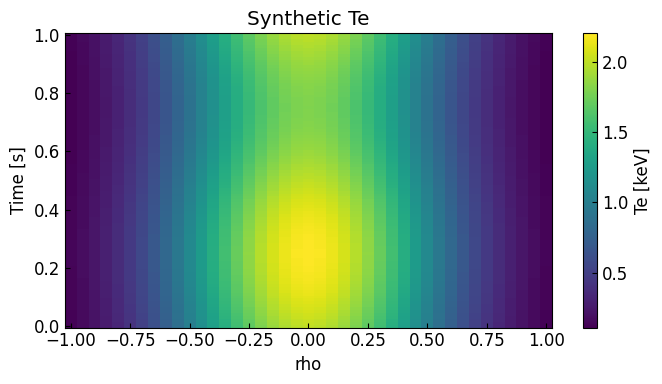

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
mesh = ax.pcolormesh(data.get_dim_data("rho"), data.time, data["Te"], shading="auto")
ax.set(xlabel="rho", ylabel="Time [s]", title="Synthetic Te")
fig.colorbar(mesh, ax=ax, label="Te [keV]")
fig.tight_layout()

## 4. 一時ファイルへ保存して復元する

In [5]:
with TemporaryDirectory() as tmpdir:
    output = Path(tmpdir) / "synthetic_profile.pkl"
    data.export_local(output)
    restored = KaisekiData.from_local_file(output)
    np.testing.assert_allclose(restored["Te"], data["Te"])
    print("Round trip OK:", output.name)

Round trip OK: synthetic_profile.pkl


## 5. オープンデータを取得する（任意）

ネットワーク接続と対象データを確認してから `RUN_LIVE` を `True` にします。

#name: tsmap_calib  #shotno: 194042  #subno: 1  #date: 10/06/2025 17:03
Data Shape: (344, 140, 32)
dimnames:  'Time', 'R'
dimunits:  's'   , 'm'
valnames:  'reff', 'Te' , 'Te_bayesian', 'dTe', 'ne_calFIR', 'ne_bayesian', 'ne_symmetry', 'dne_calFIR', 'Te_fit', 'Te_fit_err', 'dTedr', 'dTedr_err', 'ne_fit', 'ne_fit_err', 'dnedr' , 'dnedr_err', 'Te_systematic_error', 'ne_systematic_error', 'cor_symmetry', 'reff/a99', 'reff/a999', 'Wpe', 'dVdreff', 'phi', 'beta_e', 'ne_original', 'dne', 'Br', 'Bz', 'Bphi'
valunits:  'm'   , 'keV', 'keV'        , 'keV', 'e19m-3'   , 'e19m-3'     , 'e19m-3'     , 'e19m-3'    , 'keV'   , 'keV'       , 'keV/m', 'keV/m'    , 'e19m-3', 'e19m-3'    , 'e19m-4', 'e19m-4'   , 'arb'                , 'arb'                , 'arb'         , 'arb'     , 'arb'      , 'kJ' , 'm2'     , 'Wb' , '%'     , 'arb'        , 'arb', 'T' , 'T' , 'T'   


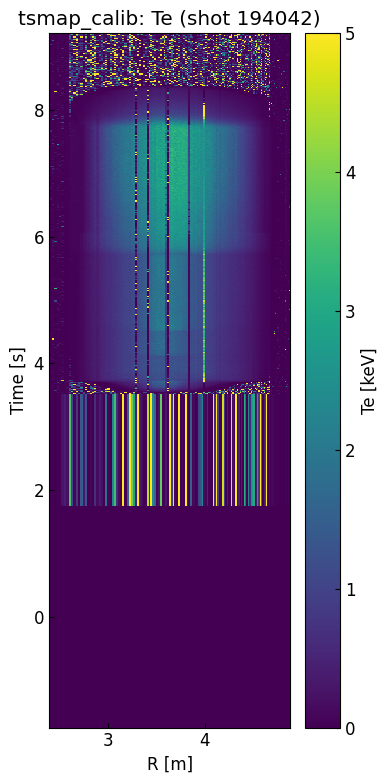

In [ ]:
RUN_LIVE = False

if RUN_LIVE:
    live_data = KaisekiData.retrieve_opendata(diag="tsmap_calib", shotno=194042, subno=1)
    live_data.show()

    fig, ax = plt.subplots(figsize=(4, 8))
    mesh = ax.pcolormesh(
        live_data.get_dim_data("R"),
        live_data.get_dim_data("Time"),
        live_data["Te"],
        shading="auto",
        vmin=0.0,
        vmax=5.0
    )
    ax.set(
        xlabel=f"R [{live_data.get_dim_unit('R')}]",
        ylabel=f"Time [{live_data.get_dim_unit('Time')}]",
        title=f"{live_data.name}: Te (shot {live_data.shotno})",
    )
    fig.colorbar(mesh, ax=ax, label=f"Te [{live_data.get_val_unit('Te')}]")
    fig.tight_layout()
else:
    print("Live retrieval is disabled. Set RUN_LIVE=True to execute.")